In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

import torch
from torch.utils.data import Dataset, DataLoader

In [12]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [13]:
import numpy as np
import scipy
import torch

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

NumPy: 2.2.6
SciPy: 1.14.1
PyTorch: 2.7.0+cu128
CUDA: True


In [14]:
PROJECT_DIR = Path(
    r"C:\Users\User\Desktop\白血球画像分類"
)

PROCESSED_DIR = PROJECT_DIR / "processed"

METADATA_PATH = (
    PROJECT_DIR / "metadata_with_split.csv"
)

metadata_df = pd.read_csv(METADATA_PATH)

metadata_df.head()

,subject,class_name,batch,montage_id,cell_id,row,col,ch1_path,ch3_path,ch5_path,subject_group,split
0,CRF034,B,batch1,1,0,0,0,CRF034\B\batch1\montage_1\cell_0000_ch1.tif,CRF034\B\batch1\montage_1\cell_0000_ch3.tif,CRF034\B\batch1\montage_1\cell_0000_ch5.tif,CRF034,train
1,CRF034,B,batch1,1,1,0,1,CRF034\B\batch1\montage_1\cell_0001_ch1.tif,CRF034\B\batch1\montage_1\cell_0001_ch3.tif,CRF034\B\batch1\montage_1\cell_0001_ch5.tif,CRF034,train
2,CRF034,B,batch1,1,2,0,2,CRF034\B\batch1\montage_1\cell_0002_ch1.tif,CRF034\B\batch1\montage_1\cell_0002_ch3.tif,CRF034\B\batch1\montage_1\cell_0002_ch5.tif,CRF034,train
3,CRF034,B,batch1,1,3,0,3,CRF034\B\batch1\montage_1\cell_0003_ch1.tif,CRF034\B\batch1\montage_1\cell_0003_ch3.tif,CRF034\B\batch1\montage_1\cell_0003_ch5.tif,CRF034,train
4,CRF034,B,batch1,1,4,0,4,CRF034\B\batch1\montage_1\cell_0004_ch1.tif,CRF034\B\batch1\montage_1\cell_0004_ch3.tif,CRF034\B\batch1\montage_1\cell_0004_ch5.tif,CRF034,train


<h3>Train / Validation / Test に分ける</h3>
<h4>split labelを使ってそれぞれのDataframeに振り分ける</h4>

In [15]:
train_df = metadata_df[
    metadata_df["split"] == "train"
].copy()

val_df = metadata_df[
    metadata_df["split"] == "val"
].copy()

test_df = metadata_df[
    metadata_df["split"] == "test"
].copy()
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 60649
Validation: 17303
Test: 22153


In [16]:
cell_type = {
    "B":0,
    "T":1,
    "eosinophil":2,
    "monocyte":3,
    "neutrophil":4
}
row = metadata_df.iloc[0]
class_name = row["class_name"]
label = cell_type[class_name]
print(label)

0


<h3>Datasetを作るclass</h3>

In [24]:
class WBCDataset(Dataset):
    def __init__(self,dataframe, image_dir,channel):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.channel = channel
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self,idx):
        row = self.dataframe.iloc[idx]
        img_path = self.image_dir / row[self.channel]
        #Read image file on the directory
        image = tifffile.imread(img_path)
        class_name = row["class_name"]
        label = cell_type[class_name]
        #Convert extracted image to tensor
        image_tensor = torch.from_numpy(image).float()
        image_tensor = image_tensor.unsqueeze(0)
        return image_tensor,label
    

In [25]:
train_dataset = WBCDataset(
    dataframe=train_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path"
)

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", train_df.iloc[0]["class_name"])

Image shape: torch.Size([1, 55, 55])
Label: 0
Class: B


<h3>DataLoader</h3>

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 1, 55, 55])
Labels shape: torch.Size([32])


<h3>CNN</h3>

In [28]:
import torch.nn as nn
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc = nn.Linear(
            32 * 13 * 13,
            5
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [29]:
model = CNN()
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 1, 55, 55])
Output shape: torch.Size([32, 5])


In [30]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)
print("Loss:", loss.item())

Loss: 1.6449519395828247


<h3>BackPropagation</h3>

In [37]:
from tqdm import tqdm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ----- Calculate class weights -----

class_counts = train_df["class_name"].value_counts()

num_samples = len(train_df)
num_classes = len(cell_type)

class_weights = []

for class_name, class_idx in sorted(
    cell_type.items(),
    key=lambda x: x[1]
):

    count = class_counts[class_name]

    weight = num_samples / (
        num_classes * count
    )

    class_weights.append(weight)

    print(
        class_name,
        "count =", count,
        "weight =", weight
    )


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


# Weighted loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# Reset model
model = CNN().to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


model.train()

running_loss = 0.0
correct = 0
total = 0

progress_bar = tqdm(
    train_loader,
    desc="Training"
)


for images, labels in progress_bar:

    # Move data to GPU
    images = images.to(device)
    labels = labels.to(device)

    # Reset previous gradient
    optimizer.zero_grad()

    # Forward propagation
    outputs = model(images)

    # Loss function
    loss = criterion(outputs, labels)

    # Back propagation
    loss.backward()

    # Update weight using gradient from backprop
    optimizer.step()

    # ----- Loss -----
    running_loss += loss.item() * images.size(0)

    # ----- Accuracy -----
    predicted = outputs.argmax(dim=1)

    correct += (predicted == labels).sum().item()
    total += labels.size(0)

    current_accuracy = 100 * correct / total

    # Progress display
    progress_bar.set_postfix(
        loss=f"{loss.item():.4f}",
        accuracy=f"{current_accuracy:.2f}%"
    )


average_loss = running_loss / total
train_accuracy = 100 * correct / total

print("Average Train Loss:", average_loss)
print("Train Accuracy:", train_accuracy, "%")

Using device: cuda
B count = 2079 weight = 5.834439634439635
T count = 14104 weight = 0.8600255246738514
eosinophil count = 2406 weight = 5.041479634247714
monocyte count = 2231 weight = 5.436934110264455
neutrophil count = 39829 weight = 0.3045469381606367


Training: 100%|██████████████████████████████████████| 1896/1896 [07:49<00:00,  4.04it/s, accuracy=52.54%, loss=1.6032]

Average Train Loss: 1.6074399257107606
Train Accuracy: 52.53837656020709 %


<h3>Validation Loss / Validation Accuracy</h3>

In [38]:
val_dataset = WBCDataset(
    dataframe=val_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path"
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [39]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

progress_bar = tqdm(
    val_loader,
    desc="Validation"
)

with torch.no_grad():

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        # Forward only
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        # Prediction
        predicted = outputs.argmax(dim=1)

        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

        current_accuracy = 100 * val_correct / val_total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{current_accuracy:.2f}%"
        )

val_loss = val_running_loss / val_total
val_accuracy = 100 * val_correct / val_total

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy, "%")

Validation: 100%|██████████████████████████████████████| 541/541 [00:20<00:00, 26.04it/s, accuracy=45.73%, loss=1.5032]

Validation Loss: 1.546332751830341
Validation Accuracy: 45.731953996416806 %


In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

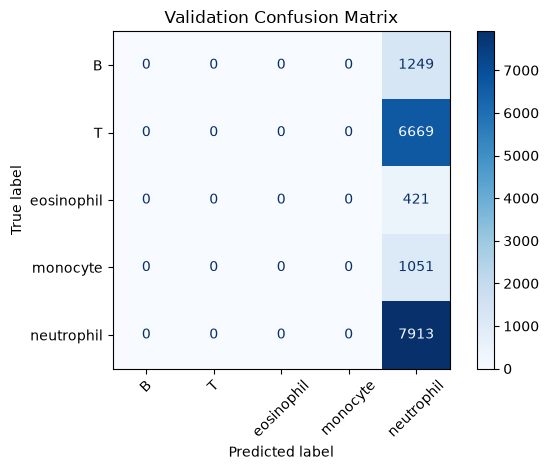

In [42]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)
class_names = [
    "B",
    "T",
    "eosinophil",
    "monocyte",
    "neutrophil"
]

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
for i in range(5):
    image, label = train_dataset[i]

    print(
        f"Image {i} | "
        f"min={image.min().item():.4f}, "
        f"max={image.max().item():.4f}, "
        f"mean={image.mean().item():.4f}, "
        f"std={image.std().item():.4f}, "
        f"label={label}"
    )

Image 0 | min=0.0025, max=0.0052, mean=0.0033, std=0.0002, label=0
Image 1 | min=0.0027, max=0.0039, mean=0.0033, std=0.0001, label=0
Image 2 | min=0.0025, max=0.0039, mean=0.0033, std=0.0001, label=0
Image 3 | min=0.0027, max=0.0037, mean=0.0033, std=0.0001, label=0
Image 4 | min=0.0027, max=0.0039, mean=0.0033, std=0.0001, label=0


In [44]:
check_sum = 0.0
check_squared_sum = 0.0
check_pixels = 0

for i, (images, labels) in enumerate(train_loader):

    check_sum += images.sum().item()
    check_squared_sum += (images ** 2).sum().item()
    check_pixels += images.numel()

    if i == 99:
        break

check_mean = check_sum / check_pixels
check_var = check_squared_sum / check_pixels - check_mean ** 2
check_std = check_var ** 0.5

print("Normalized sample mean:", check_mean)
print("Normalized sample std:", check_std)

Normalized sample mean: 0.003398191552910923
Normalized sample std: 0.00016173084646900642


In [50]:
class WBCDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        channel,
        mean=None,
        std=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.channel = channel

        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        img_path = (
            self.image_dir
            / row[self.channel]
        )

        # Read image file on the directory
        tiff_channel = tifffile.imread(img_path)

        # Convert NumPy to PyTorch Tensor
        image_tensor = torch.from_numpy(
            tiff_channel
        ).float()

        # Add channel dimension
        image_tensor = image_tensor.unsqueeze(0)

        # Normalize image
        if self.mean is not None and self.std is not None:
            image_tensor = (
                image_tensor - self.mean
            ) / (self.std + 1e-8)

        class_name = row["class_name"]
        label = cell_type[class_name]

        return image_tensor, label

In [51]:
stats_dataset = WBCDataset(
    dataframe=train_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path",
    mean=None,
    std=None
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=32,
    shuffle=False
)

In [52]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
num_pixels = 0

for images, labels in tqdm(
    stats_loader,
    desc="Calculating mean/std"
):

    images = images.double()

    pixel_sum += images.sum().item()
    pixel_squared_sum += (images ** 2).sum().item()

    num_pixels += images.numel()


train_mean = pixel_sum / num_pixels

train_variance = (
    pixel_squared_sum / num_pixels
    - train_mean ** 2
)

train_std = train_variance ** 0.5

print("Train mean:", train_mean)
print("Train std:", train_std)

Calculating mean/std: 100%|████████████████████████████████████████████████████████| 1896/1896 [00:56<00:00, 33.47it/s]

Train mean: 0.003398375998519426
Train std: 0.00016185119052088544


In [53]:
train_dataset = WBCDataset(
    dataframe=train_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path",
    mean=train_mean,
    std=train_std
)

val_dataset = WBCDataset(
    dataframe=val_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path",
    mean=train_mean,
    std=train_std
)

In [54]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [55]:
image, label = train_dataset[0]

print("Shape:", image.shape)
print("Min:", image.min().item())
print("Max:", image.max().item())
print("Mean:", image.mean().item())
print("Std:", image.std().item())
print("Label:", label)

Shape: torch.Size([1, 55, 55])
Min: -5.440695762634277
Max: 11.434041023254395
Mean: -0.4102666974067688
Std: 0.9567627310752869
Label: 0


In [56]:
check_sum = 0.0
check_squared_sum = 0.0
check_pixels = 0

for i, (images, labels) in enumerate(train_loader):

    images = images.double()

    check_sum += images.sum().item()
    check_squared_sum += (images ** 2).sum().item()

    check_pixels += images.numel()

    if i == 99:
        break


check_mean = check_sum / check_pixels

check_variance = (
    check_squared_sum / check_pixels
    - check_mean ** 2
)

check_std = check_variance ** 0.5

print("Normalized sample mean:", check_mean)
print("Normalized sample std:", check_std)

Normalized sample mean: 0.002878489502770556
Normalized sample std: 1.0005889333055749


In [62]:
# ----- Class weights -----

class_counts = train_df["class_name"].value_counts()

num_samples = len(train_df)
num_classes = len(cell_type)

class_weights = []

for class_name, class_idx in sorted(
    cell_type.items(),
    key=lambda x: x[1]
):

    count = class_counts[class_name]

    weight = num_samples / (
        num_classes * count
    )

    class_weights.append(weight)

    print(
        class_name,
        "count =", count,
        "weight =", weight
    )


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


# Weighted loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# Reset model
model = CNN().to(device)


# Reset optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

B count = 2079 weight = 5.834439634439635
T count = 14104 weight = 0.8600255246738514
eosinophil count = 2406 weight = 5.041479634247714
monocyte count = 2231 weight = 5.436934110264455
neutrophil count = 39829 weight = 0.3045469381606367


In [66]:
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc="Training"
    )

    for images, labels in progress_bar:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Reset previous gradient
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(images)

        # Loss function
        loss = criterion(outputs, labels)

        # Back propagation
        loss.backward()

        # Update weight using gradient from backprop
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predicted = outputs.argmax(dim=1)

        correct += (
            predicted == labels
        ).sum().item()

        total += labels.size(0)

        current_accuracy = (
            100 * correct / total
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{current_accuracy:.2f}%"
        )

    average_loss = running_loss / total
    accuracy = 100 * correct / total

    return average_loss, accuracy

In [67]:
def validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        val_loader,
        desc="Validation"
    )

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            # Forward propagation only
            outputs = model(images)

            # Loss function
            loss = criterion(outputs, labels)

            running_loss += (
                loss.item() * images.size(0)
            )

            predicted = outputs.argmax(dim=1)

            correct += (
                predicted == labels
            ).sum().item()

            total += labels.size(0)

            current_accuracy = (
                100 * correct / total
            )

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                accuracy=f"{current_accuracy:.2f}%"
            )

    average_loss = running_loss / total
    accuracy = 100 * correct / total

    return average_loss, accuracy

In [68]:
num_epochs = 20

train_loss_history = []
train_accuracy_history = []

val_loss_history = []
val_accuracy_history = []

best_val_loss = float("inf")

for epoch in range(num_epochs):

    print(
        f"\nEpoch {epoch + 1}/{num_epochs}"
    )

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
    )

    val_loss, val_accuracy = (
        validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )
    )

    train_loss_history.append(train_loss)
    train_accuracy_history.append(
        train_accuracy
    )

    val_loss_history.append(val_loss)
    val_accuracy_history.append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_simple_cnn.pth"
        )

        print("Best model saved!")


Epoch 1/20


Validation: 100%|██████████████████████████████████████| 541/541 [00:21<00:00, 25.32it/s, accuracy=92.48%, loss=0.0039]


Train Loss: 0.0819 | Train Accuracy: 97.81%
Validation Loss: 0.2536 | Validation Accuracy: 92.48%
Best model saved!

Epoch 2/20


Validation: 100%|██████████████████████████████████████| 541/541 [00:22<00:00, 24.45it/s, accuracy=95.31%, loss=0.0048]


Train Loss: 0.0799 | Train Accuracy: 97.89%
Validation Loss: 0.1701 | Validation Accuracy: 95.31%
Best model saved!

Epoch 3/20


...

Train Loss: 0.0258 | Train Accuracy: 99.23%
Validation Loss: 0.2738 | Validation Accuracy: 95.17%

Epoch 19/20


Validation: 100%|██████████████████████████████████████| 541/541 [00:21<00:00, 24.86it/s, accuracy=89.65%, loss=0.0000]


Train Loss: 0.0457 | Train Accuracy: 98.75%
Validation Loss: 2.8020 | Validation Accuracy: 89.65%

Epoch 20/20


Validation: 100%|██████████████████████████████████████| 541/541 [00:21<00:00, 25.39it/s, accuracy=95.20%, loss=0.0000]

Train Loss: 0.0444 | Train Accuracy: 98.82%
Validation Loss: 0.2575 | Validation Accuracy: 95.20%


In [69]:
model.load_state_dict(
    torch.load(
        "best_simple_cnn.pth",
        map_location=device
    )
)

model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

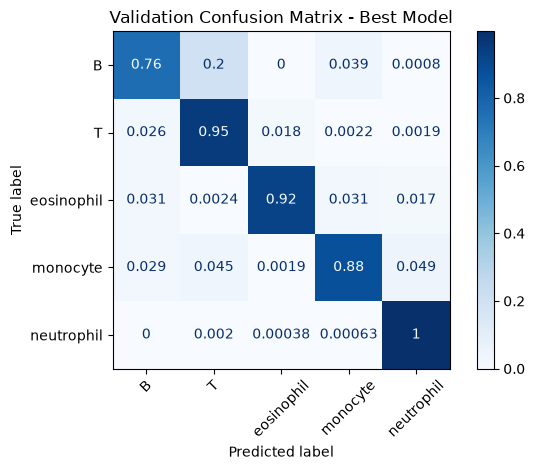

In [70]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = [
    "B",
    "T",
    "eosinophil",
    "monocyte",
    "neutrophil"
]

cm = confusion_matrix(
    all_labels,
    all_predictions,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title(
    "Validation Confusion Matrix - Best Model"
)

plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("Validation Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Validation Accuracy: 0.953071721666763
Macro Precision: 0.8861807159081584
Macro Recall: 0.9005877044358208
Macro F1: 0.891505328610155
              precision    recall  f1-score   support

           B       0.81      0.76      0.79      1249
           T       0.95      0.95      0.95      6669
  eosinophil       0.76      0.92      0.83       421
    monocyte       0.92      0.88      0.90      1051
  neutrophil       0.99      1.00      0.99      7913

    accuracy                           0.95     17303
   macro avg       0.89      0.90      0.89     17303
weighted avg       0.95      0.95      0.95     17303

